# 라이브러리/데이터 불러오기

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import random
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
random.seed(SEED)

# 저장 파일명 설정
model_name = 'cn7_dropout_AE_2.keras'
scaler_name = 'cn7_scaler_2.pkl'
threshold_name = 'cn7_thresholds_2.json'

I0000 00:00:1788934178.227435   18202 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788934178.288191   18202 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788934179.538497   18202 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
label_data = pd.read_csv('data/labeled_data.csv')
label_data.shape

(7996, 45)

# EDA 및 데이터 전처리

## 데이터 종류 및 개수 확인

In [3]:
label_data['EQUIP_NAME'].value_counts()

EQUIP_NAME
650톤-우진2호기    7992
1800TON-우진       2
650톤-우진          2
Name: count, dtype: int64

> 데이터가 확보된 '650톤-우진2호기'만 사용

In [4]:
label_data['PART_NAME'].value_counts()

PART_NAME
CN7 W/S SIDE MLD'G RH        3371
CN7 W/S SIDE MLD'G LH        3365
RG3 MOLD'G W/SHLD, LH         628
RG3 MOLD'G W/SHLD, RH         628
SP2 CVR ROOF RACK CTR, RH       2
JX1 W/S SIDE MLD'G RH           2
Name: count, dtype: int64

> 데이터가 충분히 확보된 'CN7', 'RG3'만 사용

## 데이터 정제 / 전처리

In [7]:
# 중복 제거

print("중복행 개수:", label_data.duplicated().sum())
label_data.drop_duplicates(inplace=True)
print("중복제거 후:", label_data.shape)

중복행 개수: 2764
중복제거 후: (5232, 45)


In [8]:
# 불필요한 데이터 제거

def make_input(data, machine_name, product_name): 
    machine_ = data['EQUIP_NAME'] == machine_name
    product_ = data['PART_NAME'] == product_name
    data = data[machine_ & product_]

    data.drop(['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'Reason', 
               'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME',
               'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5', 
               'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 
               'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11', 
               'Mold_Temperature_12']
               , axis=1, inplace=True)
    return data

In [9]:
machine_name = '650톤-우진2호기'
product_name = ["CN7 W/S SIDE MLD'G LH", "CN7 W/S SIDE MLD'G RH", "RG3 MOLD'G W/SHLD, LH", "RG3 MOLD'G W/SHLD, RH"]

cn7lh = make_input(label_data, machine_name, product_name[0])
cn7rh = make_input(label_data, machine_name, product_name[1])
rg3lh = make_input(label_data, machine_name, product_name[2])
rg3rh = make_input(label_data, machine_name, product_name[3])

cn7 = pd.concat([cn7lh, cn7rh], ignore_index=True)
rg3 = pd.concat([rg3lh, rg3rh], ignore_index=True)

# rg3에는 'Plasticizing_Position' 변수값이 모두 0이므로 추가적으로 삭제
rg3.drop(['Plasticizing_Position'], axis=1, inplace=True)

In [10]:
cn7['PassOrFail'] = cn7['PassOrFail'].map({'Y': 0, 'N': 1})
rg3['PassOrFail'] = rg3['PassOrFail'].map({'Y': 0, 'N': 1})

# 학습/평가 데이터 분리

In [10]:
cn7['PassOrFail'].value_counts()

PassOrFail
0    3946
1      28
Name: count, dtype: int64

In [11]:
cn7_Y = cn7[cn7['PassOrFail'] == 0]
print('CN7의 양품 개수:', len(cn7_Y))

cn7_N = cn7[cn7['PassOrFail'] == 1]
print('CN7의 불량 개수:', len(cn7_N))

CN7의 양품 개수: 3946
CN7의 불량 개수: 28


**잡음제거 오토인코더 (Denoising AE)**    
입력층 뒤의 Dropout(0.3)이 학습 중 입력 변수의 30%를 랜덤하게 0으로 만드는 masking noise 역할을 합니다. 모델은 손상된 입력에서 원본을 복원하도록 학습되므로, 단순 항등함수 암기 대신 정상 공정 데이터의 변수 간 상관 구조를 익힙니다. 추론(predict) 시 Dropout은 자동으로 비활성화되어 깨끗한 입력으로 복원 오차를 측정합니다.

In [12]:
# 잡음제거 오토인코더 모델에 학습시킬 데이터의 형태는 클래스 변수가 없어야 하므로 PassOrFail 변수 제거
print(cn7_Y.shape, cn7_N.shape)

cn7_Y.drop(['PassOrFail'], axis=1, inplace=True)
cn7_N.drop(['PassOrFail'], axis=1, inplace=True)

print(cn7_Y.shape, cn7_N.shape)

(3946, 27) (28, 27)
(3946, 26) (28, 26)


In [13]:
# 데이터 분리

# 아래 코드대로 하면 cn7_test_Y에는 RH만 들어가게 되므로, RH와 LH를 섞어서 학습/테스트 데이터셋을 구성해야 함
# cn7_train_Y = cn7_Y[:4000]
# cn7_test_Y = cn7_Y[4000:]

from sklearn.model_selection import train_test_split

cn7_train, cn7_test_Y = train_test_split(cn7_Y, train_size=3000, random_state=42)
cn7_train_Y, cn7_valid_Y = train_test_split(cn7_train, test_size=0.2, random_state=42)
cn7_test_N = cn7_N

print('CN7 양품 학습 데이터셋 개수:', len(cn7_train_Y))
print('CN7 양품 테스트 데이터셋 개수:', len(cn7_test_Y))
print('CN7 불량 테스트 데이터셋 레이블 개수:', len(cn7_test_N))

CN7 양품 학습 데이터셋 개수: 2400
CN7 양품 테스트 데이터셋 개수: 946
CN7 불량 테스트 데이터셋 레이블 개수: 28


In [14]:
scaler = MinMaxScaler()

# 양품과 불량 각각 scaling 하면 양품과 불량이 서로 다른 좌표계에 놓여서 비교가 불가능
# 분할을 먼저 하고, 학습용 양품에만 fit, 나머지는 transform
# cn7_Y = scaler.fit_transform(cn7_Y)
# cn7_N = scaler.fit_transform(cn7_N)

cn7_train_Y = scaler.fit_transform(cn7_train_Y)
cn7_valid_Y = scaler.transform(cn7_valid_Y)
cn7_test_Y = scaler.transform(cn7_test_Y)
cn7_test_N = scaler.transform(cn7_test_N)

# 오토 인코더 모델 구축

In [15]:
n_features = cn7_train_Y.shape[1]

# 인코더
dropout_encoder = Sequential([
    Input(shape=(n_features,)),   # 입력 shape 명시
    Dropout(0.3),
    Dense(15, activation='relu'),
    Dense(5, activation='relu'),
])

# 디코더
dropout_decoder = Sequential([
    Input(shape=(5,)),            # input_shape=[5] 대신 Input 레이어로
    Dense(15, activation='relu'),
    Dense(n_features, activation='sigmoid'),  # relu → sigmoid
])

dropout_AE = Sequential([dropout_encoder, dropout_decoder])

W0000 00:00:1788771324.706843  297341 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [16]:
dropout_AE.compile(loss='mse', optimizer=Adam(learning_rate=1e-3), metrics=['mae'])

history = dropout_AE.fit(
    cn7_train_Y, cn7_train_Y,
    epochs=100,
    batch_size=30,
    validation_data=(cn7_valid_Y, cn7_valid_Y),
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, mode='min', restore_best_weights=True)]
)

Epoch 1/100


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1510 - mae: 0.3648 - val_loss: 0.0822 - val_mae: 0.2404
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0362 - mae: 0.1284 - val_loss: 0.0207 - val_mae: 0.0769
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0172 - mae: 0.0702 - val_loss: 0.0189 - val_mae: 0.0671
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0164 - mae: 0.0647 - val_loss: 0.0180 - val_mae: 0.0624
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0160 - mae: 0.0618 - val_loss: 0.0175 - val_mae: 0.0603
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0155 - mae: 0.0603 - val_loss: 0.0160 - val_mae: 0.0581
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 - mae: 0.0579 - val_loss: 0.0135 - val_mae: 0.0544
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0119 - mae: 0.0540 - val_loss: 0.0107 - val_mae: 0.0502
Epoch 9/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0103 - mae: 0.0

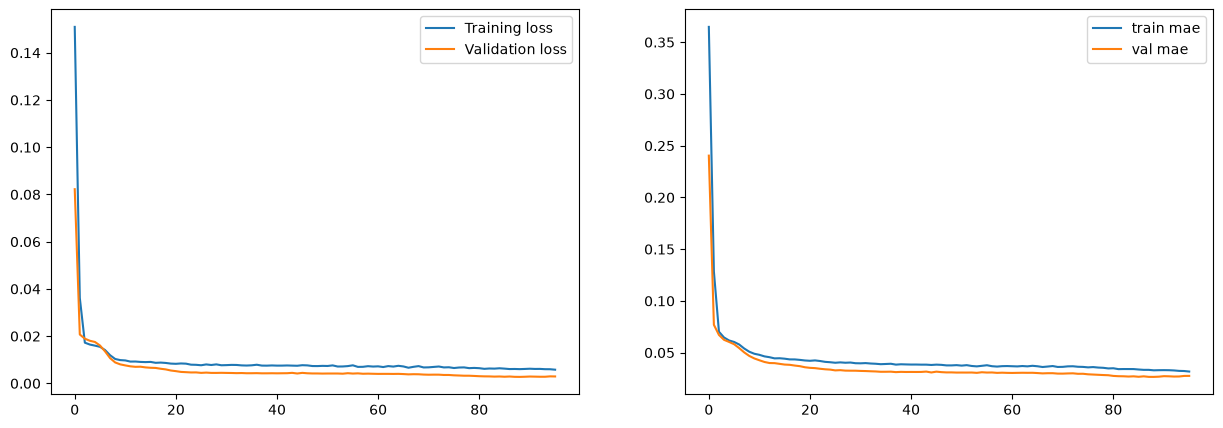

In [ ]:
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label="Training loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='val mae')
plt.legend()
plt.show()

In [ ]:
# 모델, 스케일러 저장
import os, json, joblib

os.makedirs('models', exist_ok=True)
dropout_AE.save(f'models/{model_name}')
joblib.dump(scaler, f'models/{scaler_name}')

# 임계값 정의

In [19]:
# 저장한 모델 불러오기
import json, joblib
import numpy as np
from tensorflow.keras.models import load_model

model_path = 'models/cn7_dropout_AE_2.keras'
scaler_path = 'models/cn7_scaler_2.pkl'
threshold_path = 'models/cn7_thresholds_2.json'

model = load_model(model_path)
scaler = joblib.load(scaler_path)
threshold = json.load(open(threshold_path))['threshold']

In [28]:
cn7_val_pred = model.predict(cn7_valid_Y)
cn7_val_loss = np.mean(np.square(cn7_val_pred - cn7_valid_Y), axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [29]:
threshold = np.percentile(cn7_val_loss, 99)
print("복원 오류 임계치:", threshold)

복원 오류 임계치: 0.006705020007273058


In [ ]:
with open(f'models/{threshold_name}', 'w') as f:
    json.dump({'threshold': threshold}, f)

 # 예측값과 복원 오차 확인

In [20]:
# 예측값
cn7_predict_Y = model.predict(cn7_test_Y)
cn7_predict_N = model.predict(cn7_test_N)

# 복원 오차
cn7_test_Y_mse = np.mean(np.square(cn7_predict_Y - cn7_test_Y), axis=1)
cn7_test_N_mse = np.mean(np.square(cn7_predict_N - cn7_test_N), axis=1)

# 판정 결과
cn7_test_Y_anomalies = cn7_test_Y_mse > threshold
cn7_test_N_anomalies = cn7_test_N_mse > threshold

print("오탐(False Positive, 양품인데 불량 판정):", np.sum(cn7_test_Y_anomalies))
print("정탐(True Positive, 불량인데 불량 판정):", np.sum(cn7_test_N_anomalies))

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
오탐(False Positive, 양품인데 불량 판정): 11
정탐(True Positive, 불량인데 불량 판정): 17


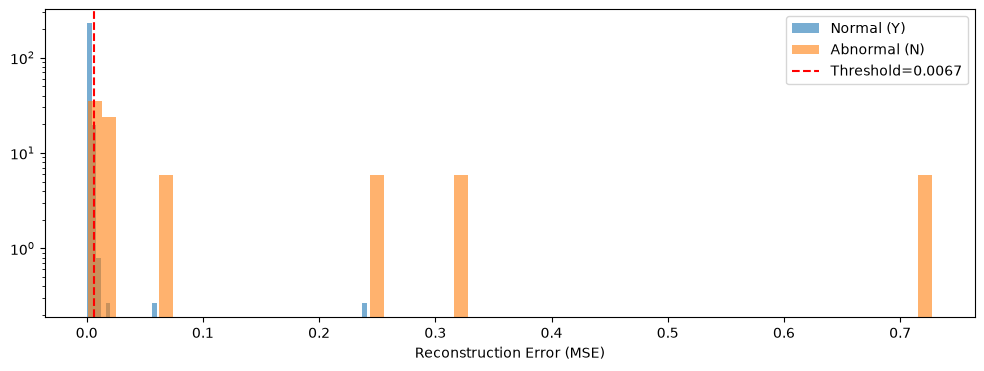

In [21]:
# 시각화
plt.figure(figsize=(12, 4))

plt.hist(cn7_test_Y_mse, bins=60, alpha=.6, density=True, label='Normal (Y)')
plt.hist(cn7_test_N_mse, bins=60, alpha=.6, density=True, label='Abnormal (N)')
plt.axvline(threshold, color='r', ls='--', label=f'Threshold={threshold:.4f}')
plt.yscale('log')
plt.xlabel('Reconstruction Error (MSE)')
plt.legend()
plt.show()

# 결과 분석 및 해석

In [22]:
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score)

In [23]:
cn7_true = np.concatenate([np.zeros(len(cn7_test_Y)), np.ones(len(cn7_test_N))])
cn7_prediction = np.concatenate([cn7_test_Y_anomalies, cn7_test_N_anomalies]).astype(int)
cn7_score = np.concatenate([cn7_test_Y_mse, cn7_test_N_mse])  # 점수(연속값) — AUC 계산용

양품을 양품으로 예측 (TN) : 935
양품을 불량으로 예측 (FP, 과검) : 11
불량을 양품으로 예측 (FN, 미검) : 11
불량을 불량으로 예측 (TP) : 17


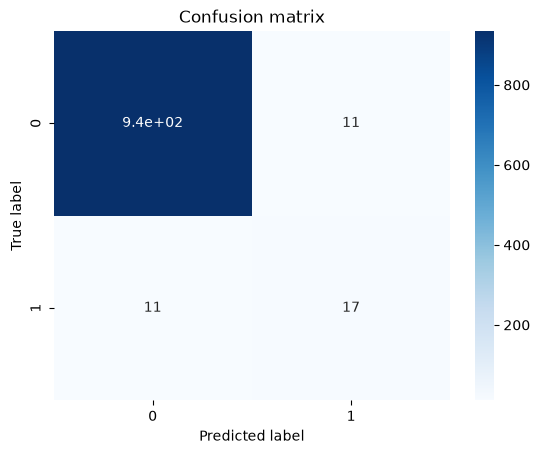

In [24]:
# 혼동행렬
tn, fp, fn, tp = confusion_matrix(cn7_true, cn7_prediction).ravel()
print(f"양품을 양품으로 예측 (TN) : {tn}")
print(f"양품을 불량으로 예측 (FP, 과검) : {fp}")
print(f"불량을 양품으로 예측 (FN, 미검) : {fn}")
print(f"불량을 불량으로 예측 (TP) : {tp}")

cnf_matrix = confusion_matrix(cn7_true, cn7_prediction, labels=[0, 1])
sns.heatmap(cnf_matrix, annot=True, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.show()

In [25]:
# 전부 양품으로 예측했을 경우와 정확도 비교
# 불량 비율이 낮아 정확도는 참고용일 뿐, 이 지표만으로 성능을 판단하지 않음

base_acc = 1 - len(cn7_test_N) / len(cn7_true)
print(f"[정확도]\tbaseline(전부 양품): {base_acc:.4f}  vs  모델: {accuracy_score(cn7_true, cn7_prediction):.4f}")

print(f"[정밀도]\t{precision_score(cn7_true, cn7_prediction)}")
print(f"[재현율]\t{recall_score(cn7_true, cn7_prediction)}")
print(f"[F1 score]\t{f1_score(cn7_true, cn7_prediction)}")

[정확도]	baseline(전부 양품): 0.9713  vs  모델: 0.9774
[정밀도]	0.6071428571428571
[재현율]	0.6071428571428571
[F1 score]	0.6071428571428571


In [26]:
# 임계값과 무관한 판별력

print(f"ROC-AUC: {roc_auc_score(cn7_true, cn7_score):.4f}")
print(f"PR-AUC : {average_precision_score(cn7_true, cn7_score):.4f}  (무작위 기준선: {1-base_acc:.4f})")

ROC-AUC: 0.9482
PR-AUC : 0.6266  (무작위 기준선: 0.0287)


In [30]:
# 임계값 스윕 : 지금 고른 임계값이 최선인지 확인

rows = []
for p in [95, 99, 99.5, 99.9]:
    t = np.percentile(cn7_val_loss, p)
    tn_, fp_, fn_, tp_ = confusion_matrix(cn7_true, (cn7_score > t).astype(int), labels=[0,1]).ravel()
    prec = tp_/(tp_+fp_) if (tp_+fp_) else 0
    rec = tp_/(tp_+fn_) if (tp_+fn_) else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    rows.append([p, t, fp_, fn_, prec, rec, f1])

sweep_df = pd.DataFrame(rows, columns=['백분위','임계값','과검(FP)','미검(FN)','정밀도','재현율','F1'])
display(sweep_df)

,백분위,임계값,과검(FP),미검(FN),정밀도,재현율,F1
0,95.0,0.005274,34,11,0.333333,0.607143,0.430380
1,99.0,0.006705,11,11,0.607143,0.607143,0.607143
2,99.5,0.007526,7,12,0.695652,0.571429,0.627451
3,99.9,0.102964,1,22,0.857143,0.214286,0.342857


# 결과 진단 코드

학습 결과에 대한 지표 해석·분석·결론·수정사항은 별도 문서 [`AE_result_analysis.md`](AE_result_analysis.md)에 정리했습니다.
아래 셀들은 **그 문서에 인용된 수치 중 위쪽 셀 출력만으로는 확인되지 않는 부분**을 재현합니다.
문서의 절 번호와 1:1로 대응합니다.

| 진단 | 재현하는 내용 | 문서 위치 |
|---|---|---|
| 1 | 최적 epoch·손실, Dropout으로 인한 학습/검증 손실 역전 | 결과 1) |
| 2 | 검증 오차 분포와 실제 과검율 | 결과 2) |
| 3 | 불량 28건의 오차 정렬·임계값 배수·양품과의 겹침·LH/RH 페어 | 결과 4), 수정 5 |
| 4 | 양품과 피처값이 동일한 불량 건수와 판정 결과 | 결과 5), 결론 2, 수정 3 |
| 5 | 변수별 복원 오차 기여도 | 결과 6) |
| 6 | 과검 11건의 오차와 임계값 상향 효과, 라벨 오류 의심 후보 | 결과 7), 결론 5 |
| 7 | 피처 기준 중복행과 학습/검증/테스트 겹침 | 수정 1 |
| 8 | 상수·준상수 컬럼, 학습 범위를 벗어난 불량 셀 비율 | 수정 4, 6 |

In [31]:
# [진단 1] 학습 과정 - 최적 epoch와 Dropout으로 인한 손실 역전 (문서 결과 1)
_ae = globals().get('dropout_AE') or globals().get('model')   # 학습 직후 / 모델 재로드 양쪽 지원

if 'history' in globals():
    _best = int(np.argmin(history.history['val_loss']))
    print(f"총 학습 epoch      : {len(history.history['loss'])} (EarlyStopping patience=7)")
    print(f"val_loss 최저 epoch: {_best + 1}  →  val_loss {history.history['val_loss'][_best]:.4f}")
    print(f"마지막 epoch 손실  : train {history.history['loss'][-1]:.4f} / val {history.history['val_loss'][-1]:.4f}")
else:
    print("history 없음 (모델을 재로드한 경우) - epoch 요약은 학습 셀 실행 후 확인")

# 학습 손실 > 검증 손실인 이유가 Dropout인지 직접 확인
# 동일한 학습 데이터를 Dropout ON(학습 시) / OFF(추론 시)로 각각 복원해 오차 비교
_off = np.mean(np.square(_ae(cn7_train_Y, training=False).numpy() - cn7_train_Y))
_on = np.mean([np.mean(np.square(_ae(cn7_train_Y, training=True).numpy() - cn7_train_Y))
               for _ in range(5)])
print(f"\n같은 학습 데이터의 복원 오차")
print(f"  Dropout OFF (추론 시) : {_off:.5f}")
print(f"  Dropout ON  (학습 시) : {_on:.5f}  →  {_on / _off:.2f}배")
print("→ 학습 손실이 검증 손실보다 높은 것은 과소적합이 아니라 Dropout 때문")

history 없음 (모델을 재로드한 경우) - epoch 요약은 학습 셀 실행 후 확인

같은 학습 데이터의 복원 오차
  Dropout OFF (추론 시) : 0.00234
  Dropout ON  (학습 시) : 0.00617  →  2.64배
→ 학습 손실이 검증 손실보다 높은 것은 과소적합이 아니라 Dropout 때문


In [32]:
# [진단 2] 임계값 보정 상태 - 검증 오차 분포와 실제 과검율 (문서 결과 2)
print("검증 양품 복원 오차 분포")
display(pd.Series(cn7_val_loss).describe(percentiles=[.5, .9, .99]).round(5).to_frame('값'))

_fp_rate = cn7_test_Y_anomalies.sum() / len(cn7_test_Y_mse)
print(f"임계값(검증 99 백분위) : {threshold:.6f}")
print(f"설계 과검율            : 1.00%  (99 백분위이므로)")
print(f"테스트 실측 과검율     : {cn7_test_Y_anomalies.sum()} / {len(cn7_test_Y_mse)} = {_fp_rate:.2%}")

검증 양품 복원 오차 분포


,값
count,600.00000
mean,0.00275
std,0.00986
min,0.00028
50%,0.00189
90%,0.00447
99%,0.00671
max,0.24083


임계값(검증 99 백분위) : 0.006705
설계 과검율            : 1.00%  (99 백분위이므로)
테스트 실측 과검율     : 11 / 946 = 1.16%


In [33]:
# [진단 3] 불량 28건의 복원 오차 분포 (문서 결과 4, 수정사항 5)
_mult = cn7_test_N_mse / threshold
_group = np.where(cn7_test_N_mse <= threshold, '미검(FN)',
                  np.where(_mult < 2, '경계 TP', '탐지 TP'))
_defect = (pd.DataFrame({'복원오차': cn7_test_N_mse, '임계값배수': _mult, '구분': _group})
             .sort_values('복원오차').reset_index(drop=True))
display(_defect.round(5))
print(_defect['구분'].value_counts().to_string())

# 양품 오차와의 겹침 여부 (완전히 분리되는가?)
_ymax = cn7_test_Y_mse.max()
_tp = cn7_test_N_mse[cn7_test_N_anomalies]
print(f"\n양품 테스트 오차 최대값 : {_ymax:.5f}")
print(f"검출된 불량 {len(_tp)}건 중 양품 최대값보다 작은 건수 : {(_tp < _ymax).sum()}")
print("→ 두 분포는 완전히 분리되지 않고 겹치는 구간이 존재")

# LH/RH는 같은 샷에서 나오므로 복원 오차가 정확히 일치 → 독립 사건 수 확인
_vc = pd.Series(cn7_test_N_mse.round(8)).value_counts()
print(f"\n오차가 정확히 일치하는 쌍 : {(_vc == 2).sum()}쌍 / 단독 {(_vc == 1).sum()}건")
print(f"→ 불량 {len(cn7_N)}행의 실질 독립 사건 수는 {(_vc == 2).sum() + (_vc == 1).sum()}건")

,복원오차,임계값배수,구분
0,0.00140,0.20949,미검(FN)
1,0.00371,0.55380,미검(FN)
2,0.00415,0.61875,미검(FN)
3,0.00420,0.62648,미검(FN)
4,0.00426,0.63548,미검(FN)
5,0.00452,0.67368,미검(FN)
6,0.00460,0.68604,미검(FN)
7,0.00471,0.70276,미검(FN)
8,0.00474,0.70643,미검(FN)
9,0.00477,0.71068,미검(FN)


구분
탐지 TP     16
미검(FN)    11
경계 TP      1

양품 테스트 오차 최대값 : 0.24083
검출된 불량 17건 중 양품 최대값보다 작은 건수 : 11
→ 두 분포는 완전히 분리되지 않고 겹치는 구간이 존재

오차가 정확히 일치하는 쌍 : 8쌍 / 단독 12건
→ 불량 28행의 실질 독립 사건 수는 20건


In [34]:
# [진단 4] 라벨 충돌 - 양품과 피처값이 완전히 같은 불량 (문서 결과 5, 결론 2, 수정사항 3)
_keys_Y = set(map(tuple, cn7_Y.values))
_collide = np.array([tuple(v) in _keys_Y for v in cn7_N.values])

print(f"불량 {len(cn7_N)}건 중 양품과 피처값이 동일한 건수 : {_collide.sum()}")
print(f"  └ 미검(FN) {int((~cn7_test_N_anomalies & _collide).sum())}건 / "
      f"정탐(TP) {int((cn7_test_N_anomalies & _collide).sum())}건")

_uniq = ~_collide
print(f"양품에 없는 고유 불량 {_uniq.sum()}건 중 정탐 {int((cn7_test_N_anomalies & _uniq).sum())}건 "
      f"→ 재현율 {(cn7_test_N_anomalies & _uniq).sum() / _uniq.sum():.3f}")

불량 28건 중 양품과 피처값이 동일한 건수 : 12
  └ 미검(FN) 11건 / 정탐(TP) 1건
양품에 없는 고유 불량 16건 중 정탐 16건 → 재현율 1.000


In [35]:
# [진단 5] 변수별 복원 오차 기여도 - 모델이 무엇을 보고 불량이라 했는가 (문서 결과 6)
_cols = cn7_Y.columns
_err_N = np.square(cn7_predict_N - cn7_test_N)

_contrib = pd.DataFrame({
    '정탐불량(TP)': _err_N[cn7_test_N_anomalies].mean(axis=0),
    '미검불량(FN)': _err_N[~cn7_test_N_anomalies].mean(axis=0),
    '정상양품': np.square(cn7_predict_Y - cn7_test_Y).mean(axis=0),
}, index=_cols).sort_values('정탐불량(TP)', ascending=False)

display(_contrib.head(8).round(5))

,정탐불량(TP),미검불량(FN),정상양품
Filling_Time,1.72099,0.00047,0.00101
Max_Injection_Speed,0.68915,0.00168,0.00230
Max_Back_Pressure,0.54416,0.00040,0.00558
Injection_Time,0.53385,0.00008,0.00036
Average_Screw_RPM,0.32538,0.00012,0.00417
Max_Switch_Over_Pressure,0.30581,0.00103,0.00189
Cycle_Time,0.08180,0.00009,0.00039
Mold_Temperature_4,0.04674,0.06215,0.01195


In [36]:
# [진단 6] 과검 11건 분석과 임계값 상향 효과 (문서 결과 7, 결론 5)
_fp = np.sort(cn7_test_Y_mse[cn7_test_Y_anomalies])
display(pd.DataFrame({'복원오차': _fp, '임계값배수': _fp / threshold}).round(5))

# 문서에서 언급한 "임계값을 99.5%로 올리면?"의 실제 효과
for _p in [99, 99.5]:
    _t = np.percentile(cn7_val_loss, _p)
    print(f"임계값 {_p}백분위 ({_t:.6f}) → 과검 {int((cn7_test_Y_mse > _t).sum())}건 / "
          f"미검 {int((cn7_test_N_mse <= _t).sum())}건")

# 양품인데 오차가 압도적으로 큰 샷 = 라벨 오류 의심 후보
_susp = cn7_test_Y_mse[cn7_test_Y_mse > threshold * 5]
print(f"\n라벨 오류 의심 후보(임계값 5배 초과 양품) : {len(_susp)}건 → 오차 {np.round(np.sort(_susp), 5)}")

,복원오차,임계값배수
0,0.00688,1.02655
1,0.00696,1.03764
2,0.00703,1.04793
3,0.00752,1.12133
4,0.00825,1.22986
5,0.00850,1.26707
6,0.00878,1.30884
7,0.01067,1.59141
8,0.01683,2.51015
9,0.05766,8.59958


임계값 99백분위 (0.006705) → 과검 11건 / 미검 11건
임계값 99.5백분위 (0.007526) → 과검 7건 / 미검 12건

라벨 오류 의심 후보(임계값 5배 초과 양품) : 2건 → 오차 [0.05766 0.24083]


In [37]:
# [진단 7] 데이터 누수 - 피처 기준 중복과 학습/검증/테스트 겹침 (문서 수정사항 1)
_tr, _te = train_test_split(cn7_Y, train_size=3000, random_state=42)
_trY, _vaY = train_test_split(_tr, test_size=0.2, random_state=42)

def _overlap(base, target):
    keys = set(map(tuple, base.values))
    return sum(tuple(v) in keys for v in target.values)

print(f"양품 {len(cn7_Y)}행 중 피처 기준 고유행 : {len(cn7_Y.drop_duplicates())}행")
print(f"불량 {len(cn7_N)}행 중 피처 기준 고유행 : {len(cn7_N.drop_duplicates())}행")
print(f"학습셋과 동일한 행이 테스트셋에 : {_overlap(_trY, _te)} / {len(_te)}")
print(f"학습셋과 동일한 행이 검증셋에   : {_overlap(_trY, _vaY)} / {len(_vaY)}")

양품 3946행 중 피처 기준 고유행 : 1987행
불량 28행 중 피처 기준 고유행 : 20행
학습셋과 동일한 행이 테스트셋에 : 569 / 946
학습셋과 동일한 행이 검증셋에   : 361 / 600


In [38]:
# [진단 8] 상수 / 준상수 컬럼과 학습 범위 이탈 (문서 수정사항 4, 6)
_nu = cn7_Y.nunique()
print("상수 컬럼(분산 0)      :", _nu[_nu <= 1].index.tolist())

_ratio = cn7_Y.apply(lambda s: s.value_counts(normalize=True).iloc[0])
print("준상수 컬럼(최빈값 99%+):", _ratio[_ratio >= 0.99].round(4).to_dict())

# 학습 양품 범위([0,1]) 밖으로 나가는 불량 셀 비율
_oor = pd.Series(((cn7_test_N < 0) | (cn7_test_N > 1)).mean(axis=0), index=_cols)
print(f"\n불량 데이터의 범위 밖 셀 비율 : {((cn7_test_N < 0) | (cn7_test_N > 1)).mean():.3f}")
display(_oor[_oor > 0].sort_values(ascending=False).round(3).to_frame('범위밖 비율'))

상수 컬럼(분산 0)      : ['Switch_Over_Position', 'Barrel_Temperature_7']
준상수 컬럼(최빈값 99%+): {'Switch_Over_Position': 1.0, 'Clamp_Open_Position': 0.9954, 'Barrel_Temperature_7': 1.0}

불량 데이터의 범위 밖 셀 비율 : 0.082


,범위밖 비율
Filling_Time,0.357
Max_Injection_Speed,0.357
Max_Switch_Over_Pressure,0.286
Cushion_Position,0.286
Average_Back_Pressure,0.214
Max_Back_Pressure,0.214
Injection_Time,0.143
Clamp_Close_Time,0.143
Plasticizing_Time,0.071
Cycle_Time,0.071
